# 🛰️ Voyager 1 Machine Learning Tutorial
*Using AI to find ET!*

## 👋 Introduction
The goal of this tutorial is to learn how to use Artifical Intelligence to find Extraterrestrial Intelligence! Woah--That's a lot of intelligence! 🤖🧠👽🤯

We'll take real radio wave data collected by [Breakthrough Listen](https://breakthroughinitiatives.org/initiative/1) at the [Green Bank Telescope](https://en.wikipedia.org/wiki/Green_Bank_Telescope) in West Virginia and use a machine learning algorithm to see if any of it looks like a possible alien message!

Spoiler alert: As in the [turboSETI tutorial](https://github.com/elanlavie/VoyagerTutorial/blob/master/VoyagerTutorial.ipynb), you WILL find what appears to possibly be an alien! 🛸

Double spoiler alert: Again, it's not an alien, but IS [Voyager 1 🛰️](https://en.wikipedia.org/wiki/Voyager_1), the farthest human-made object from Earth! Which remains very freaking cool!

Afterwards you can search on any properly formatted radio data (including a provided example from Mars) and see if you can find your own aliens... Good luck!

## 📚 Background
We aim to find signals that look similar to a given “query” signal in Voyager's spectrograms. This is a lot like a [reverse Google Image Search](https://images.google.com) if you've ever tried that!

For example, if you wanted to find an image of another beautiful orange/gray spotted calico cat, you could upload your image to Google Image Search:

<div align="center"><br><img src="https://github.com/elanlavie/VoyagerMLTutorial/blob/main/images/FlopsySearch.png?raw=1" alt="GoogleImageSearch" width="400"><br></div>

<br>and it will return look-alike kitties:<br>

<div align="center"><br><img src="https://github.com/elanlavie/VoyagerMLTutorial/blob/main/images/CatHits.png?raw=1" alt="GoogleImageSearch" width="400"><br></div>

<br>We'll be doing something very similar, but instead of uploading an image of a cat, we'll upload an image of a signal we believe looks like the one Voyager (or an alien!) emits:<br>

<div align="center"><br><img src="https://github.com/elanlavie/VoyagerMLTutorial/blob/main/images/VoyagerSignal.png?raw=1" alt="VoyagerSignal" width="400"><br></div>

Then the machine learning algorithm, called a **Beta-Variational Autoencoder (β-VAE)**, will look through a bunch of data that we want it to search through for similar looking signals! If all goes well, it will return the top 10 lookalikes ("hits"), which we can then check out for ourselves to see if they really are extraterrestrial spacecraft!! (Or, more likely, Radio Frequency Interference from Earth-based satellites/wi-fi/cell phones/microwave ovens/whatever). Here's an image of what the top 10 hits for the signal above might look like:

<div align="center"><br><img src="https://github.com/elanlavie/VoyagerMLTutorial/blob/main/images/Top10Hits.png?raw=1" alt="Top10Hits" width="400"><br></div>

<br>And that's all there is to it! To better understand how the machine learning algorithm works, it may be helpful to watch:<br>

1. This wonderful video from Carnegie Mellon University to develop one's intuition on "latent space": [Cats in Latent Space](https://www.youtube.com/watch?v=hb-KT66rCT8) :)
2. This short video on Convolutional Neural Networks (like a β-VAE): [Convolutional Neural Networks](https://www.youtube.com/watch?v=LEAFHHNk8II)
3. This longer 3Blue1Brown video on Neural Networks more generally: [But What is a Neural Network?](https://www.youtube.com/watch?v=aircAruvnKk)

## 🗺️ Overview
We follow a simplified version of the method by Ma et al. (2023). First, we use an energy detection approach to extract small signal snippets from the full spectrogram – essentially finding time-frequency patches with power significantly above the noise floor. These snippets (for example, containing narrowband Doppler-drifted carrier signals) will be our “catalog” of candidate signals. Next, we load a pretrained β-Variational Autoencoder (β-VAE) encoder model based on the one created by Peter Ma et al (same weights, but probably a slightly different architecture). This neural network encodes each spectrogram snippet into a low-dimensional latent feature vector that captures its salient morphological features (shape, bandwidth, drift rate, etc.). Finally, given a selected query snippet, we compute the cosine similarity between the query’s embedding and all other snippet embeddings to retrieve the most similar signals. We will display the top 10 matches as images and discuss the results.

*Note: The dataset consists of six 5-minute scans of Voyager 1 acquired by the Green Bank Telescope in July 2020 (3 scans pointed ON the Voyager spacecraft and 3 OFF target). For simplicity, we will ignore the ON/OFF labeling (i.e. we won’t perform interference filtering by removing OFF-target signals). Instead, we’ll treat all scans uniformly as a pool of spectrogram data in which to search for lookalike signals.

## ✅ Requirements
This notebook uses TensorFlow (with GPU support) and common scientific Python packages (NumPy, h5py, etc.) which are pre-installed in Colab. We will also install Blimpy (Breakthrough Listen I/O toolkit) to help read .h5 spectrogram files. The β-VAE encoder model will be downloaded and loaded with Keras. Let's get started by importing necessary libraries and preparing the data!


## 🔧 Setup

First, we install blimpy and explicitly downgrade pyparsing to avoid version conflicts.
This cell must run before any code that triggers a pyparsing import.
Note: Colab may silently preload pyparsing 3.x, so a runtime restart may still be needed after this.

In [6]:
%pip install blimpy==2.1.4 pyparsing==2.4.7

Next, let's clone the Github repo into this Google Colab runtime so that we have access to all the files we'll need and change into that directory:

In [7]:
!git clone https://github.com/elanlavie/VoyagerMLTutorial.git

import os
os.chdir('VoyagerMLTutorial')

fatal: destination path 'VoyagerMLTutorial' already exists and is not an empty directory.


Next, let's install Blimpy for reading the HDF5 (.h5) filterbank files, and import required libraries:

In [8]:
#!pip install blimpy # BL data reader library

import numpy as np
import h5py
from blimpy import Waterfall
import matplotlib.pyplot as plt
from pathlib import Path

# Set matplotlib for inline plotting (if in Colab, this is usually automatic)
%matplotlib inline

Next, we assume the six Voyager .h5 files are available in the Colab environment (e.g. uploaded or in Drive). For example, they might be named like voyager1_scan11.h5, voyager1_scan12.h5, ... voyager1_scan16.h5 corresponding to the 3 ON + 3 OFF scans (scans 11, 13, 15 are ON; 12, 14, 16 are OFF) 1 2 . We will list the files and load them one by one to build our snippet catalog. Each file contains a **spectrogram** (waterfall plot) of one 5-min scan: power as a function of time and frequency. The time resolution in these files is on the order of 10–18 seconds per bin (the data here use ~10.7 s integration) and frequency resolution ~2.79 Hz per bin.

We'll iterate through each file, read its data, and identify high-energy patches. For this simple energy detector, we define a patch (snippet) as a fixed frequency bandwidth of ~715 Hz (which is 256 frequency bins at 2.79 Hz resolution 7 8 ) across the full time span of the scan. We slide this 256-bin window across the band and extract a snippet whenever the window contains a signal above a set threshold. The threshold can be set as, for example, mean + 5σ of the noise power. This approach will catch narrowband signals that
stand out above noise in that frequency interval (as used in Ma et al. for initial energy detection).

Let's implement the snippet extraction:

## ⏳💾 Data Loading

First we'll load the dataset that we'll be searching through. For this demo, we'll load data collected from observations made by the Greenbank Radio Telescope of Voyager 1 in 2020. There were six 5-minute observations taken corresponding to six .h5 files which we download.

In [9]:
# You can edit this variable to match whichever directory you will use to store your data files
data_directory = 'voyager_2020_data'

# Read the necessary URLs from data_urls.lst
with open('opendata.lst') as file:
    data_urls = file.read().splitlines()

# Local imports
import download_progress

# Download each one into a directory called 'data' if they aren't already present.
for url in data_urls:
    download_progress.download_file_with_progress_bar(url, download_dir=data_directory)

voyager_2020_data/spliced_blc0001020304050607_guppi_57635_34975_Gj144_0003.gpuspec.0000.h5:   0%|          | 0…

Let's plot the full spectrum of one of these files just to take a look!

In [12]:
# List your Voyager .h5 files (update the pattern if needed)
import glob
file_list = sorted(glob.glob("voyager_2020_data/*.h5"))
print("Found files:", file_list)

# Use the first file from your file_list
if not file_list:
    raise ValueError("No files found in file_list.")
fname = file_list[0] # Change this index if you'd like to see a different file's entire spectrogram.

# Load the spectrogram
wf = Waterfall(fname, load_data=True)
data = wf.data.squeeze()

# Get header info
fch1 = wf.header['fch1']        # in MHz
foff = wf.header['foff']        # in MHz
tsamp = wf.header.get('tsamp', 1.0)
n_freq = data.shape[1]
freqs_mhz = fch1 + np.arange(n_freq) * foff

# Flip frequency axis if needed
if foff < 0:
    data = np.flip(data, axis=1)
    freqs_mhz = freqs_mhz[::-1]

extent = [freqs_mhz[0], freqs_mhz[-1], 0, data.shape[0] * tsamp]

# Auto-scale using percentiles to see narrowband signals
vmin = np.percentile(data, 5)
vmax = np.percentile(data, 99.5)

# Plot
plt.figure(figsize=(16, 6))
plt.imshow(data, aspect='auto', origin='lower', cmap='viridis', extent=extent,
           vmin=vmin, vmax=vmax)
plt.colorbar(label='Power')
plt.title(f"Full Spectrogram: {Path(fname).name}")
plt.xlabel("Frequency (MHz)")
plt.ylabel("Time (s)")
plt.tight_layout()
plt.show()

Found files: ['voyager_2020_data/spliced_blc0001020304050607_guppi_57635_34975_Gj144_0003.gpuspec.0000.h5']


IndexError: tuple index out of range

--- Window diagnostics ---
time x freq (rows x cols): (2, 7159)
freq window (MHz): 2300.380628 .. 2300.400627
df (Hz): 2.79, stride_t: 10, tsamp: 18.253611008s
--------------------------


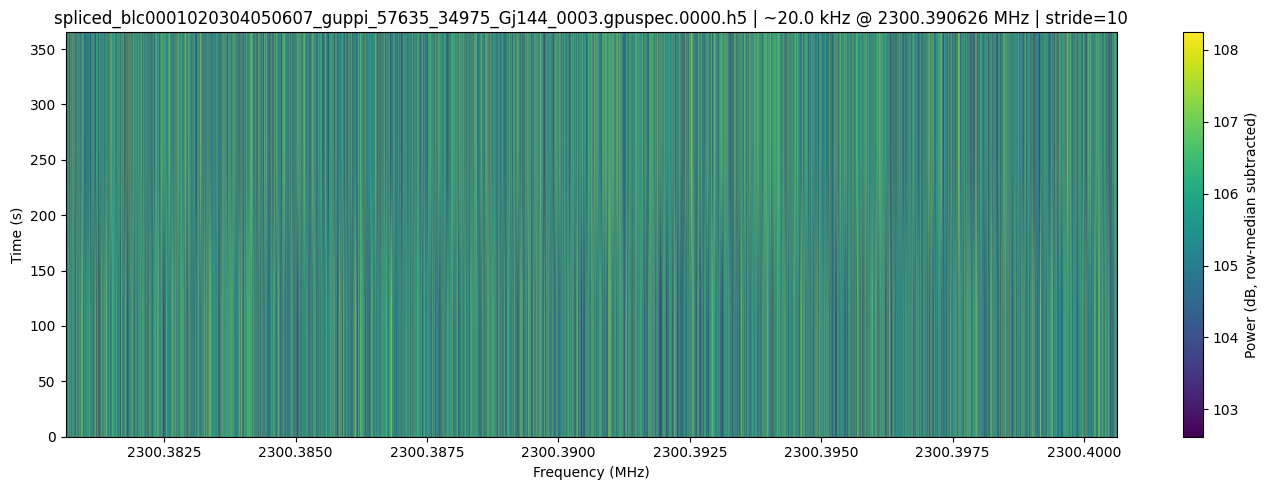

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from blimpy import Waterfall
import h5py
from pathlib import Path

def plot_h5_window(fname, center_mhz=None, bw_khz=20.0, t_stride=10, pol=0):
    # 1) Read header via blimpy (cheap) to get fch1/foff/tsamp
    wf = Waterfall(fname)
    hdr = wf.header
    fch1 = float(hdr['fch1'])       # MHz (first channel)
    foff = float(hdr['foff'])       # MHz per channel (can be negative)
    tsamp = float(hdr.get('tsamp', 1.0))

    # 2) Open HDF5 directly to slice /data without loading everything
    with h5py.File(fname, "r") as f:
        dset = f["data"]            # shape (time, pol, freq)
        n_time, n_pol, n_chan = dset.shape
        assert pol < n_pol, f"pol index {pol} out of range (n_pol={n_pol})"

        # We will work in ascending frequency for indexing
        df = abs(foff)              # MHz
        if foff < 0:
            f0_asc = fch1 + (n_chan - 1) * foff  # lowest MHz
        else:
            f0_asc = fch1                        # lowest MHz

        # Choose center frequency
        if center_mhz is None:
            center_mhz = f0_asc + (n_chan - 1) * df * 0.5

        # Convert requested bandwidth to column count
        desired_cols = int(np.ceil((bw_khz / 1000.0) / df))
        desired_cols = max(desired_cols, 32)        # minimum width
        desired_cols = min(desired_cols, n_chan)

        # Map center to nearest ascending-index
        k_center = int(np.round((center_mhz - f0_asc) / df))
        k_center = int(np.clip(k_center, 0, n_chan - 1))
        half = desired_cols // 2
        k_lo = max(k_center - half, 0)
        k_hi = min(k_lo + desired_cols, n_chan)
        if k_hi - k_lo < 1:  # safety
            k_hi = min(n_chan, k_lo + 1)

        # Build frequency indices for the native dataset order
        if foff < 0:
            # native order is high->low; ascending slice k_lo:k_hi maps to:
            # native indices: [n_chan-1 - k_hi + 1 : n_chan-1 - k_lo + 1]
            nat_lo = n_chan - k_hi
            nat_hi = n_chan - k_lo
        else:
            nat_lo, nat_hi = k_lo, k_hi

        # Time stride
        t_step = max(int(t_stride), 1)

        # Slice (this stays on disk; HDF5 pages in only what we read)
        sub = dset[0:n_time:t_step, pol, nat_lo:nat_hi]  # shape (T, F_native)

        # If foff < 0, our slice is still descending; flip to ascending for plotting
        if foff < 0:
            sub = sub[:, ::-1]

    # 3) Axes and display
    sub = np.asarray(sub, dtype=np.float64)
    n_rows, n_cols = sub.shape
    freqs_mhz = f0_asc + (k_lo + np.arange(n_cols)) * df
    extent = [freqs_mhz[0], freqs_mhz[-1], 0, n_rows * tsamp * t_step]

    # Contrast: remove per-row background and log-scale
    med = np.median(sub, axis=1, keepdims=True)
    sub = sub - med
    sub = sub - np.min(sub) + 1e-12
    sub_db = 10.0 * np.log10(sub)

    # Robust autoscale
    vals = sub_db[np.isfinite(sub_db)]
    vmin = np.percentile(vals, 5)
    vmax = np.percentile(vals, 99.5)
    if vmax - vmin < 1e-6:
        m, s = np.mean(vals), np.std(vals) or 1.0
        vmin, vmax = m - 2*s, m + 2*s

    print("--- Window diagnostics ---")
    print("time x freq (rows x cols):", sub_db.shape)
    print(f"freq window (MHz): {freqs_mhz[0]:.6f} .. {freqs_mhz[-1]:.6f}")
    print(f"df (Hz): {df*1e6:.2f}, stride_t: {t_step}, tsamp: {tsamp}s")
    print("--------------------------")

    plt.figure(figsize=(14, 5))
    plt.imshow(sub_db, aspect='auto', origin='lower', cmap='viridis',
               extent=extent, vmin=vmin, vmax=vmax)
    plt.colorbar(label='Power (dB, row-median subtracted)')
    bw_actual_khz = n_cols * df * 1000.0
    plt.title(f"{Path(fname).name} | ~{bw_actual_khz:.1f} kHz @ {center_mhz:.6f} MHz | stride={t_step}")
    plt.xlabel("Frequency (MHz)")
    plt.ylabel("Time (s)")
    plt.tight_layout()
    plt.show()

# Example: ~20 kHz window, stride 10
plot_h5_window(fname, center_mhz=None, bw_khz=20.0, t_stride=10)


Note that we can see a couple narrowband signals a little above 8419.5 MHz! That's the zoomed-out Voyager signal being observed for 5 minutes (300 seconds)!

## ✂️ Creating Snippets
As a coarse first sift through the data, we're going to create "snippets" — narrow vertical 2D patches of the spectrogram that have a high signal-to-noise ratio (SNR). Each snippet spans the full time axis of the observation and a narrow frequency window of ~2.79 Hz/bin * 256 bins/snippet = ~715 Hz/snippet. Afterwards we'll feed these snippets into the AI model, along with a query snippet, to find similar signals using latent space similarity.

In [19]:
snippets = []        # to store extracted snippet arrays
snippet_locs = []    # to store metadata (file name and freq range of each snippet)

# Parameters
freq_window = 256  # number of frequency bins ~715 Hz
sigma_threshold = 5.0  # threshold in terms of noise standard deviation

for fname in file_list:
    # Load the spectrogram data using blimpy
    wf = Waterfall(fname, load_data=True)
    data = wf.data.squeeze()  # shape: (time_bins, freq_bins)
    print(f"{fname}: data shape = {data.shape}")
    # Estimate noise level from the whole scan (assuming most of it is noise)
    mean_noise = np.mean(data)
    std_noise = np.std(data)
    threshold = mean_noise + sigma_threshold * std_noise
    # Slide a window of 256 frequency bins and extract patches exceeding threshold
    n_freq = data.shape[1]
    for f_start in range(0, n_freq, freq_window):
        f_end = min(f_start + freq_window, n_freq)
        patch = data[:, f_start:f_end]  # all time, slice of freq
        if patch.max() > threshold:
          # Extract the patch covering all time bins and this freq range
          snippets.append(patch.copy())
          snippet_locs.append((fname, f_start, f_end))
    del data  # free memory for next file

voyager_2020_data/spliced_blc0001020304050607_guppi_57635_34975_Gj144_0003.gpuspec.0000.h5: data shape = ()


IndexError: tuple index out of range

In [20]:
import numpy as np
import h5py
from blimpy import Waterfall

snippets = []        # extracted snippet arrays (time x freq)
snippet_locs = []    # (fname, f_start_bin, f_end_bin, f_lo_MHz, f_hi_MHz)

# ---- Params ----
sigma_threshold = 5.0      # threshold in robust-sigma
pol = 0                    # polarization index
t_stride = 1               # time decimation factor for reading/keeping
freq_window_bins = 256     # window width in bins (use this OR freq_window_hz)
freq_window_hz  = None     # e.g., 700  (if set, overrides bins)
max_snippets_per_file = 200  # safety to avoid collecting millions

def robust_sigma(x):
    # robust sigma via MAD
    med = np.median(x)
    mad = np.median(np.abs(x - med)) + 1e-12
    return med, 1.4826 * mad

def process_file(fname):
    global snippets, snippet_locs

    # Read header cheaply
    wf = Waterfall(fname)              # mmap only headers/light reads
    fch1 = float(wf.header['fch1'])    # MHz
    foff = float(wf.header['foff'])    # MHz per bin (may be negative)
    tsamp = float(wf.header.get('tsamp', 1.0))
    df_MHz = abs(foff)
    with h5py.File(fname, "r") as f:
        dset = f["data"]               # shape (time, pol, freq)
        n_time, n_pol, n_chan = dset.shape
        if pol >= n_pol:
            raise ValueError(f"{fname}: pol {pol} out of range (n_pol={n_pol})")

        # Convert Hz window to bins if requested
        if freq_window_hz is not None:
            bins_from_hz = max(1, int(np.ceil((freq_window_hz/1e6) / df_MHz)))
            win_bins = min(bins_from_hz, n_chan)
        else:
            win_bins = min(int(freq_window_bins), n_chan)

        # Ascending-frequency bookkeeping
        if foff < 0:
            f0_asc = fch1 + (n_chan - 1) * foff   # lowest MHz
            # native index for ascending slice [k_lo:k_hi) is [n_chan-k_hi : n_chan-k_lo)
            to_native = lambda k_lo, k_hi: (n_chan - k_hi, n_chan - k_lo)
            flip_after = True
        else:
            f0_asc = fch1
            to_native = lambda k_lo, k_hi: (k_lo, k_hi)
            flip_after = False

        # -------- Pass 1: estimate noise robustly on a light subsample --------
        # sample along time and freq to keep it cheap
        est_t_step = max(1, n_time // 16)
        est_f_step = max(1, n_chan // 16384)
        est = dset[0:n_time:est_t_step, pol, 0:n_chan:est_f_step].astype(np.float64)
        if flip_after:
            est = est[:, ::-1]  # make freq ascending

        # remove per-row background to emphasize narrowband outliers
        est = est - np.median(est, axis=1, keepdims=True)
        est = est[np.isfinite(est)]
        med, rsig = robust_sigma(est)
        threshold = med + sigma_threshold * rsig

        # -------- Pass 2: scan windows and collect snippets above threshold ----
        found = 0
        # stride by window width (non-overlapping) – reduce if you want overlap
        for k_lo in range(0, n_chan, win_bins):
            k_hi = min(k_lo + win_bins, n_chan)
            nat_lo, nat_hi = to_native(k_lo, k_hi)

            # Read this window with time decimation
            sub = dset[0:n_time:t_stride, pol, nat_lo:nat_hi].astype(np.float64)
            if flip_after:
                sub = sub[:, ::-1]  # ascending freq

            # per-row background removal
            sub = sub - np.median(sub, axis=1, keepdims=True)

            # quick check
            if not np.isfinite(sub).any():
                continue
            if np.nanmax(sub) > threshold:
                # keep a copy (still manageable) and record location
                snippets.append(sub.copy())
                f_lo_MHz = f0_asc + k_lo * df_MHz
                f_hi_MHz = f0_asc + (k_hi - 1) * df_MHz
                snippet_locs.append((fname, k_lo, k_hi, f_lo_MHz, f_hi_MHz))
                found += 1
                if found >= max_snippets_per_file:
                    break  # avoid runaway

        print(f"{fname}: time={n_time}, chans={n_chan}, win_bins={win_bins}, found={found}, thresh={threshold:.3f}")

# ----------------- run over your file_list -----------------
for fname in file_list:
    process_file(fname)


KeyboardInterrupt: 

In [21]:
import numpy as np
import h5py
from blimpy import Waterfall

snippets = []        # (time x freq) arrays
snippet_locs = []    # (fname, k_lo, k_hi, f_lo_MHz, f_hi_MHz)

# ---- TUNABLES ----
sigma_threshold = 5.0      # robust sigma threshold after row-median subtraction
pol = 0
t_stride = 1               # time decimation
win_bins = 256             # final snippet width (≈ your original 715 Hz)
coarse_stride_bins = 4096  # freq stride for coarse scan (bigger == faster)
candidates_per_file = 200  # keep top-N coarse peaks
refine_half_width = 8192   # +/- bins around each candidate to read/refine
max_snippets_per_file = 300

def robust_sigma(x):
    med = np.median(x)
    mad = np.median(np.abs(x - med)) + 1e-12
    return med, 1.4826 * mad

def proc_file(fname):
    global snippets, snippet_locs

    # headers
    wf = Waterfall(fname)
    fch1 = float(wf.header['fch1'])     # MHz
    foff = float(wf.header['foff'])     # MHz/bin (may be negative)
    tsamp = float(wf.header.get('tsamp', 1.0))
    df_MHz = abs(foff)

    with h5py.File(fname, "r") as f:
        dset = f["data"]                # (time, pol, freq)
        n_time, n_pol, n_chan = dset.shape
        assert pol < n_pol

        # Build mapping so we work in ascending-frequency index space
        if foff < 0:
            f0_asc = fch1 + (n_chan - 1) * foff  # lowest MHz
            to_native = lambda k: (n_chan - 1) - k
            flip_needed = True
        else:
            f0_asc = fch1
            to_native = lambda k: k
            flip_needed = False

        # --------- 0) quick robust threshold estimate from sparse sample ---------
        est_t_step = max(1, n_time // 16)
        est_f_step = max(1, n_chan // 65536)
        est = dset[0:n_time:est_t_step, pol, 0:n_chan:est_f_step].astype(np.float64)
        if flip_needed:
            est = est[:, ::-1]
        est = est - np.median(est, axis=1, keepdims=True)
        est = est[np.isfinite(est)]
        med, rsig = robust_sigma(est)
        thresh = med + sigma_threshold * rsig

        # --------- 1) COARSE SCAN: downsample freq; score activity ----------
        # We want something like variance over time per coarse bin
        # Sample every 'coarse_stride_bins' along ascending index
        coarse_idx = np.arange(0, n_chan, coarse_stride_bins, dtype=np.int64)
        # Read these single bins (vectorized gather in chunks to avoid many small I/Os)
        # We'll batch into chunks along freq for fewer reads:
        score = []
        batch = 8192  # number of coarse points per HDF5 read batch
        for start in range(0, len(coarse_idx), batch):
            idx_chunk = coarse_idx[start:start+batch]
            # Map to native order indices and read as a minimal slab [all time, these freqs]
            nat_cols = np.array([to_native(k) for k in idx_chunk], dtype=np.int64)
            nat_cols.sort()
            # Read the tight native span, then pick columns
            span_lo = nat_cols.min()
            span_hi = nat_cols.max() + 1
            slab = dset[0:n_time:t_stride, pol, span_lo:span_hi].astype(np.float64)
            if flip_needed:
                slab = slab[:, ::-1]  # make ascending
                # columns we want within ascending slab:
                want_cols = np.array([ (n_chan - 1) - c for c in nat_cols ], dtype=np.int64)
                want_cols.sort()
                want_cols = want_cols - want_cols.min()
            else:
                want_cols = nat_cols - span_lo

            sub = slab[:, want_cols]
            sub = sub - np.median(sub, axis=1, keepdims=True)
            # activity score: variance over time (could use max as well)
            score.append(np.var(sub, axis=0))
        score = np.concatenate(score) if len(score) else np.array([], dtype=np.float64)

        # pick top-K coarse candidates
        if score.size == 0:
            print(f"{fname}: no coarse score?")
            return
        topK = min(candidates_per_file, score.size)
        cand_order = np.argpartition(score, -topK)[-topK:]
        cand_order = cand_order[np.argsort(-score[cand_order])]
        cand_k = coarse_idx[cand_order]  # ascending indices

        # --------- 2) REFINE: read a small neighborhood around each candidate ----------
        found = 0
        for kc in cand_k:
            k_lo = max(0, kc - refine_half_width)
            k_hi = min(n_chan, kc + refine_half_width + 1)
            # map to native contiguous span
            nat_lo = to_native(k_hi - 1)
            nat_hi = to_native(k_lo)
            if nat_lo > nat_hi:
                nat_lo, nat_hi = nat_hi, nat_lo
            nat_hi += 1  # python slice end

            slab = dset[0:n_time:t_stride, pol, nat_lo:nat_hi].astype(np.float64)
            if flip_needed:
                slab = slab[:, ::-1]  # ascending
            # compute the ascending start index of this slab
            asc_start = k_lo
            # background removal
            slab = slab - np.median(slab, axis=1, keepdims=True)

            # slide non-overlapping windows of size win_bins inside this slab
            n_cols = slab.shape[1]
            for w_start in range(0, n_cols, win_bins):
                w_end = min(w_start + win_bins, n_cols)
                patch = slab[:, w_start:w_end]
                if not np.isfinite(patch).any():
                    continue
                if np.nanmax(patch) > thresh:
                    snippets.append(patch.copy())
                    k0 = asc_start + w_start
                    k1 = asc_start + w_end
                    f_lo = f0_asc + k0 * df_MHz
                    f_hi = f0_asc + (k1 - 1) * df_MHz
                    snippet_locs.append((fname, int(k0), int(k1), f_lo, f_hi))
                    found += 1
                    if found >= max_snippets_per_file:
                        break
            if found >= max_snippets_per_file:
                break

        print(f"{fname}: coarse_points={len(coarse_idx)}, candidates={topK}, found={found}, thresh={thresh:.3f}")

# -------- run --------
for fname in file_list:
    proc_file(fname)


voyager_2020_data/spliced_blc0001020304050607_guppi_57635_34975_Gj144_0003.gpuspec.0000.h5: coarse_points=87808, candidates=200, found=300, thresh=392066746718.976


When this loop runs, it will output the shape of each file's entire data array (# of time bins, # of frequency bins) and accumulate any snippet that contains a significant signal. The threshold is tuned to pick up obvious narrowband signals like Voyager's carrier or strong RFI lines, while ignoring pure noise regions.

**Note:** In the Voyager scans, the spacecraft’s carrier signal is clearly visible in the ON-source files (11, 13, and 15) as a faint drifting tone, whereas OFF scans (12, 14, and 16) contain only noise. Our simple snippet detector should catch the Voyager carrier in ON scans and might also capture any prominent terrestrial RFI peaks if present. The snippet size (~715 Hz) is chosen to cover the typical width of narrowband signals; Voyager’s carrier drifts by a few hundred Hz over 5 minutes, which falls within this window. Time-wise, we include the full duration of the scan for each snippet, so each snippet is essentially a vertical time-frequency slice ~5 minutes long by 715 Hz wide.

Let’s take a look at the snippets:

In [22]:
import numpy as np
from blimpy import Waterfall
import matplotlib.pyplot as plt

# ---------- header caching ----------
def _build_header_lookups(snippet_locs):
    freq_lookup = {}
    tsamp_lookup = {}
    for fname in {fname for fname, _, _ in snippet_locs}:
        wf = Waterfall(fname, load_data=False)
        hdr = wf.header
        fch1 = hdr['fch1']
        foff = hdr['foff']
        nchans = hdr['nchans']
        freqs = fch1 + np.arange(nchans) * foff
        freq_lookup[fname] = freqs
        tsamp_lookup[fname] = hdr.get('tsamp', 1.0)
    return freq_lookup, tsamp_lookup

def _extent_for(snippet, fname, f_start, f_end, freq_lookup, tsamp_lookup):
    tsamp = tsamp_lookup[fname]
    freqs = freq_lookup[fname][f_start:f_end]
    extent = [freqs[0], freqs[-1], 0.0, snippet.shape[0] * tsamp]  # [f0, f1, t0, t1]
    return extent, freqs, tsamp

# ---------- scoring ----------
def _robust_std(x):
    med = np.median(x)
    mad = np.median(np.abs(x - med))
    return 1.4826 * mad + 1e-12

def score_snippet(snippet):
    x = snippet.astype(np.float32, copy=False)
    x = x - np.median(x, axis=1, keepdims=True)  # remove time background
    x = x - np.median(x, axis=0, keepdims=True)  # remove freq background
    sigma = _robust_std(x)
    z = x / sigma
    idx = np.unravel_index(np.argmax(z), z.shape)
    peak_snr = float(z[idx])
    return peak_snr, idx  # (row, col)

# ---------- main ranking (prints the count) ----------
def rank_snippets(snippets, snippet_locs, verbose=True):
    """
    Returns a ranked list (highest score first).
    Each item: {index, score, fname, short_name, freq_MHz, time_s, extent, shape}
    Also PRINTS the total count if verbose=True.
    """
    num_snips = len(snippets)
    if verbose:
        print(f"Total snippets found: {num_snips}")

    freq_lookup, tsamp_lookup = _build_header_lookups(snippet_locs)

    results = []
    for i, (snippet, (fname, f_start, f_end)) in enumerate(zip(snippets, snippet_locs)):
        score, (r, c) = score_snippet(snippet)
        extent, freqs, tsamp = _extent_for(snippet, fname, f_start, f_end, freq_lookup, tsamp_lookup)
        short_name = fname if len(fname) <= 30 else f"…{fname[-30:]}"
        results.append({
            "index": i,  # <-- use this index to fetch the snippet later
            "score": score,
            "fname": fname,
            "short_name": short_name,
            "freq_MHz": float(freqs[c]),
            "time_s": float(r * tsamp),
            "extent": extent,               # [f0, f1, 0, t1]
            "shape": tuple(snippet.shape),
        })

    results.sort(key=lambda d: d["score"], reverse=True)
    return results

# ---------- table printer (indices included) ----------
def print_top_table(ranked, top_k=10):
    n = min(len(ranked), top_k)
    print(f"\nTop {n} snippets (by SNR-like score):")
    print(f"{'rank':>4}  {'idx':>5}  {'score':>8}  {'freq_MHz':>12}  {'time_s':>8}  {'shape':>12}  name")
    for j in range(n):
        d = ranked[j]
        print(f"{j+1:>4}  {d['index']:>5}  {d['score']:8.2f}  {d['freq_MHz']:12.6f}  {d['time_s']:8.2f}  {str(d['shape']):>12}  {d['short_name']}")

# ---------- visualize top-K only (<=10) and SHOW ----------
def show_top_snippets(snippets, snippet_locs, ranked, top_k=10, cols=5):
    """
    Displays a small grid of the top-K (max 10) snippets with their indices & scores.
    Uses plt.imshow and calls plt.show().
    """
    k = min(len(ranked), max(1, min(top_k, 10)))
    rows = int(np.ceil(k / cols))
    fig, axs = plt.subplots(rows, cols, figsize=(cols * 3.6, rows * 2.8))

    # Normalize axs to 2D indexable array
    if rows == 1 and cols == 1:
        axs = np.array([[axs]])
    elif rows == 1:
        axs = np.array([axs])
    elif cols == 1:
        axs = np.array([[ax] for ax in axs])

    # Precompute lookups once
    freq_lookup, tsamp_lookup = _build_header_lookups(snippet_locs)

    for j in range(k):
        d = ranked[j]
        idx = d["index"]
        snippet = snippets[idx]
        fname, f_start, f_end = snippet_locs[idx]
        extent, _, _ = _extent_for(snippet, fname, f_start, f_end, freq_lookup, tsamp_lookup)

        r, c = divmod(j, cols)
        ax = axs[r, c]
        ax.imshow(snippet, aspect='auto', origin='lower', cmap='viridis', extent=extent)
        ax.set_title(f"rank {j+1} | idx {idx} | SNR~{d['score']:.1f}", fontsize=8)
        ax.set_xlabel("Freq (MHz)")
        ax.set_ylabel("Time (s)")

    # Hide unused panels
    for j in range(k, rows * cols):
        r, c = divmod(j, cols)
        axs[r, c].axis("off")

    plt.tight_layout()
    fig.suptitle(f"Top {k} Snippets (indices shown)", fontsize=14)
    fig.subplots_adjust(top=0.90)
    plt.show()

# ---------- example usage ----------
ranked = rank_snippets(snippets, snippet_locs, verbose=True)  # <-- prints the total count
print_top_table(ranked, top_k=10)                              # <-- prints indices you can copy
show_top_snippets(snippets, snippet_locs, ranked, top_k=10)    # <-- shows the plots


Total snippets found: 300


ValueError: too many values to unpack (expected 3)

In [25]:
import numpy as np
from blimpy import Waterfall
import matplotlib.pyplot as plt
from pathlib import Path

# ---------- header caching (robust to foff sign) ----------
def _build_header_lookups(snippet_locs):
    """Cache per-file frequency base, spacing, nchans, tsamp."""
    info = {}
    fnames = {loc[0] for loc in snippet_locs}  # <-- no unpacking here
    for fname in fnames:
        wf = Waterfall(fname, load_data=False)
        hdr = wf.header
        fch1  = float(hdr['fch1'])              # MHz
        foff  = float(hdr['foff'])              # MHz/bin (may be negative)
        df    = abs(foff)                       # MHz/bin (positive)
        nch   = int(hdr['nchans'])
        # lowest frequency in ascending order:
        f0_asc = fch1 + (nch - 1) * foff if foff < 0 else fch1
        tsamp = float(hdr.get('tsamp', 1.0))
        info[fname] = dict(f0_asc=f0_asc, df=df, nch=nch, tsamp=tsamp)
    return info

def _parse_loc(loc, header_info, snippet_shape):
    """
    Return a dict with:
      - fname
      - extent = [f0_MHz, f1_MHz, 0, t_end_s]
      - col_to_freq(c) -> MHz for column index c
    Accepts:
      (fname, f_start_idx, f_end_idx)                # indices (ascending)
      (fname, f_lo_MHz, f_hi_MHz)                    # explicit MHz
      (fname, k_lo, k_hi, f_lo_MHz, f_hi_MHz)        # both
    """
    fname = loc[0]
    info  = header_info[fname]
    n_time, n_cols = snippet_shape
    t_end = info["tsamp"] * n_time

    if len(loc) == 3:
        a, b = loc[1], loc[2]
        # Heuristic: if a/b are ints within [0, nch] and width matches snippet, treat as indices
        if isinstance(a, (int, np.integer)) and isinstance(b, (int, np.integer)) and 0 <= a < info["nch"] and 0 < b <= info["nch"]:
            k_lo, k_hi = int(a), int(b)
            # sanity: width
            if (k_hi - k_lo) != n_cols:
                # fall back to MHz if it doesn't match
                f_lo, f_hi = float(a), float(b)
                f_step = (f_hi - f_lo) / max(n_cols - 1, 1)
                extent = [f_lo, f_hi, 0.0, t_end]
                return dict(fname=fname, extent=extent,
                            col_to_freq=lambda c: f_lo + c * f_step)
            # use ascending index math
            f_lo = info["f0_asc"] + k_lo * info["df"]
            f_hi = info["f0_asc"] + (k_hi - 1) * info["df"]
            extent = [f_lo, f_hi, 0.0, t_end]
            return dict(fname=fname, extent=extent,
                        col_to_freq=lambda c: info["f0_asc"] + (k_lo + c) * info["df"])
        else:
            # treat as MHz range
            f_lo, f_hi = float(a), float(b)
            f_step = (f_hi - f_lo) / max(n_cols - 1, 1)
            extent = [f_lo, f_hi, 0.0, t_end]
            return dict(fname=fname, extent=extent,
                        col_to_freq=lambda c: f_lo + c * f_step)

    elif len(loc) >= 5:
        # (fname, k_lo, k_hi, f_lo, f_hi)
        k_lo, k_hi, f_lo, f_hi = int(loc[1]), int(loc[2]), float(loc[3]), float(loc[4])
        # Prefer explicit MHz for extent/axis (no rounding drift)
        f_step = (f_hi - f_lo) / max(n_cols - 1, 1)
        extent = [f_lo, f_hi, 0.0, t_end]
        return dict(fname=fname, extent=extent,
                    col_to_freq=lambda c: f_lo + c * f_step)

    else:
        raise ValueError(f"Unsupported snippet_locs entry: {loc}")

# ---------- scoring ----------
def _robust_std(x):
    med = np.median(x)
    mad = np.median(np.abs(x - med))
    return 1.4826 * mad + 1e-12

def score_snippet(snippet):
    x = snippet.astype(np.float32, copy=False)
    x = x - np.median(x, axis=1, keepdims=True)  # remove time background
    x = x - np.median(x, axis=0, keepdims=True)  # remove freq background
    sigma = _robust_std(x)
    z = x / sigma
    idx = np.unravel_index(np.nanargmax(z), z.shape)
    peak_snr = float(z[idx])
    return peak_snr, idx  # (row, col)

# ---------- main ranking ----------
def rank_snippets(snippets, snippet_locs, verbose=True):
    """
    Returns a ranked list (highest score first).
    Each item: {index, score, fname, short_name, freq_MHz, time_s, extent, shape}
    """
    num_snips = len(snippets)
    if verbose:
        print(f"Total snippets found: {num_snips}")

    header_info = _build_header_lookups(snippet_locs)

    results = []
    for i, (snippet, loc) in enumerate(zip(snippets, snippet_locs)):
        score, (r, c) = score_snippet(snippet)
        parsed = _parse_loc(loc, header_info, snippet.shape)
        freq_at_peak = parsed["col_to_freq"](c)
        short_name = loc[0] if len(loc[0]) <= 30 else f"…{loc[0][-30:]}"
        results.append({
            "index": i,  # use this to fetch snippet later
            "score": score,
            "fname": loc[0],
            "short_name": short_name,
            "freq_MHz": float(freq_at_peak),
            "time_s": float(r * header_info[loc[0]]["tsamp"]),
            "extent": parsed["extent"],     # [f0, f1, 0, t1]
            "shape": tuple(snippet.shape),
        })

    results.sort(key=lambda d: d["score"], reverse=True)
    return results

# ---------- table ----------
def print_top_table(ranked, top_k=10):
    n = min(len(ranked), top_k)
    print(f"\nTop {n} snippets (by SNR-like score):")
    print(f"{'rank':>4}  {'idx':>5}  {'score':>8}  {'freq_MHz':>12}  {'time_s':>8}  {'shape':>12}  name")
    for j in range(n):
        d = ranked[j]
        print(f"{j+1:>4}  {d['index']:>5}  {d['score']:8.2f}  {d['freq_MHz']:12.6f}  {d['time_s']:8.2f}  {str(d['shape']):>12}  {d['short_name']}")

# ---------- visualize ----------
def show_top_snippets(snippets, snippet_locs, ranked, top_k=10, cols=5):
    k = min(len(ranked), max(1, min(top_k, 10)))
    rows = int(np.ceil(k / cols))
    fig, axs = plt.subplots(rows, cols, figsize=(cols * 3.6, rows * 2.8))

    # normalize axs to 2D
    if rows == 1 and cols == 1:
        axs = np.array([[axs]])
    elif rows == 1:
        axs = np.array([axs])
    elif cols == 1:
        axs = np.array([[ax] for ax in axs])

    header_info = _build_header_lookups(snippet_locs)

    for j in range(k):
        d = ranked[j]
        idx = d["index"]
        snippet = snippets[idx]
        loc = snippet_locs[idx]
        parsed = _parse_loc(loc, header_info, snippet.shape)

        r, c = divmod(j, cols)
        ax = axs[r, c]
        ax.imshow(snippet, aspect='auto', origin='lower', cmap='viridis',
                  extent=parsed["extent"])
        ax.set_title(f"rank {j+1} | idx {idx} | SNR~{d['score']:.1f}", fontsize=8)
        ax.set_xlabel("Freq (MHz)")
        ax.set_ylabel("Time (s)")

    # hide leftovers
    for j in range(k, rows * cols):
        r, c = divmod(j, cols)
        axs[r, c].axis("off")

    plt.tight_layout()
    fig.suptitle(f"Top {k} Snippets (indices shown)", fontsize=14)
    fig.subplots_adjust(top=0.90)
    plt.show()


In addition to visualizing the snippets, we’re also told how many were extracted: 17. With only 17 snippets above the signal-to-noise threshold, there’s really no need for a reverse image search—we can easily inspect them visually. But in a real (much larger) dataset, we’d likely extract thousands of snippets, making manual inspection impractical until after a reverse image search narrows them down to a manageable number of top hits.

That said, we’re going to run a reverse image search on these 17 snippets anyway—for practice. On to the AI!

## 🧠 Loading the Pretrained β-VAE Encoder Model

Peter Ma and colleagues trained a β-VAE on millions of such signal snippets to learn a compressed representation of signal morphologies. Here we will load a pretrained encoder model (which maps a 2D spectrogram snippet to a latent feature vector) which should be very similar to the one created by Ma et al.

In [26]:
from tensorflow.keras.models import load_model
encoder = load_model("vae_encoder.keras")
encoder.summary()

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 16, 256, 1)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 256, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 128, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 128, 64)    │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 16, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 16, 32, 32)     │        36,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 16, 16, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 16, 8, 32)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 8, 32)      │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     1,048,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         8,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent (Dense)                  │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,196,330 (4.56 MB)

 Trainable params: 1,196,266 (4.56 MB)

 Non-trainable params: 64 (256.00 B)

The encoder.summary() shows the layers of the model. It is a convolutional neural network that takes an input of shape (time, frequency, 1) – in our case, ~16 time bins × 256 freq bins × 1 channel – and outputs a latent vector (the encoded features). Note: The model expects a specific input shape that matches the training snippets. In the original paper, spectrograms were averaged to about 18.25 s per time bin, giving 16 time bins per 5-min snippet 11 . Our data has ~28 time bins (at ~10.7 s each) per snippet, which we need to adjust. To match the model, we will downsample each snippet’s time dimension to 16 bins.
For simplicity, we can do a rough downsampling by selecting 16 evenly spaced time slices from each snippet. (In a more rigorous approach, one could average or interpolate, but this quick method should retain the overall signal shape.) Let's prepare all snippets for input into the encoder:

In [27]:
# Prepare snippet array for model input
import math
snippets_array = []
for patch in snippets:
    t_bins, f_bins = patch.shape
    # Choose 16 time indices evenly from the snippet
    if t_bins >= 16:
        idx = np.linspace(0, t_bins-1, 16, dtype=int)
        patch_16 = patch[idx, :]
    else:
        # if somehow fewer than 16 (unlikely here), pad with last row
        pad_count = 16 - t_bins
        patch_16 = np.vstack([patch, np.tile(patch[-1,:], (pad_count, 1))])
    # Normalize or log-scale if needed (optional):
    # In practice, one might log10 transform and normalize each snippet as done in training.
# Here we assume the model was trained on linear power; we'll proceed without additional normalization.
    # Add channel dimension:
    patch_16 = np.expand_dims(patch_16, axis=-1)  # shape: 16 x 256 x 1
    snippets_array.append(patch_16)
snippets_array = np.array(snippets_array)
print("Input tensor shape for encoder:", snippets_array.shape)

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 2 dimensions. The detected shape was (300, 16) + inhomogeneous part.

In [28]:
import numpy as np
import math

TARGET_T = 16
TARGET_F = 256

def pick_time_rows(patch, target_t=TARGET_T):
    t_bins, _ = patch.shape
    if t_bins >= target_t:
        idx = np.linspace(0, t_bins-1, target_t, dtype=int)
        out = patch[idx, :]
    else:
        pad = target_t - t_bins
        out = np.vstack([patch, np.tile(patch[-1, :], (pad, 1))])
    return out

def center_crop_or_pad_freq(patch_tf, target_f=TARGET_F):
    # patch_tf: shape (T, F)
    T, F = patch_tf.shape
    if F == target_f:
        return patch_tf
    if F > target_f:
        # center crop around the strongest column
        col = np.nanargmax(np.nanmax(patch_tf, axis=0))
        half = target_f // 2
        start = max(0, col - half)
        end = start + target_f
        if end > F:
            end = F
            start = F - target_f
        return patch_tf[:, start:end]
    else:
        # pad to the right with edge values (could also pad both sides)
        pad_cols = target_f - F
        pad_block = np.tile(patch_tf[:, -1][:, None], (1, pad_cols))
        return np.hstack([patch_tf, pad_block])

def sanitize(x):
    x = np.nan_to_num(x, nan=0.0, posinf=0.0, neginf=0.0)
    return x.astype(np.float32, copy=False)

# Build uniform tensor
fixed = []
skipped = 0
for patch in snippets:
    tf = pick_time_rows(patch, TARGET_T)
    tf = center_crop_or_pad_freq(tf, TARGET_F)
    if tf.shape != (TARGET_T, TARGET_F):
        skipped += 1
        continue
    # (optional) row-median subtract + log scale for stability
    # tf = tf - np.median(tf, axis=1, keepdims=True)
    # tf = tf - tf.min() + 1e-12
    # tf = 10*np.log10(tf)

    tf = sanitize(tf)
    tf = tf[:, :, None]  # add channel dim -> (16, 256, 1)
    fixed.append(tf)

snippets_array = np.stack(fixed, axis=0)  # shape: (N, 16, 256, 1)
print("Input tensor shape for encoder:", snippets_array.shape)
if skipped:
    print(f"Skipped {skipped} patches that could not be standardized.")


Input tensor shape for encoder: (300, 16, 256, 1)


Now we pass this tensor through the encoder to get the latent embeddings for each snippet.

In [29]:
embeddings = encoder.predict(snippets_array)
print("Embeddings shape:", embeddings.shape)

10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 183ms/step
Embeddings shape: (300, 10)


After encoding, we have an array of embeddings where each row is the feature vector for the   corresponding   snippet. (For   example,   if   the   latent   space   dimension   is  d,   the   shape   will   be
(N_snippets, d) .)

## 🤖 Similarity Search in Latent Space

With all snippets embedded into feature space, we can perform a reverse similarity search. We will pick
one snippet as our query – ideally a snippet containing a signal of interest (e.g. Voyager’s carrier) – and
compute the cosine similarity between this query vector and every other snippet’s vector. High cosine
similarity (near 1.0) means the candidate snippet’s spectrogram looks very similar to the query; low
similarity means they differ (complete opposites would be -1.0). We then rank all snippets by similarity and take the top 20 matches (excluding
the query itself).

Let's choose the first snippet as the query (you could pick any index corresponding to a known signal). Then
compute similarities and find the top matches:

In [30]:
# Choose a query snippet
query_index = 2  # CHANGE THIS NUMBER TO PICK A DIFFERENT QUERY SNIPPET
query_vec = embeddings[query_index]

# Compute cosine similarity between query_vec and all embeddings
norms = np.linalg.norm(embeddings, axis=1)
query_norm = np.linalg.norm(query_vec)
cosine_sim = (embeddings @ query_vec) / (norms * query_norm)  # dot product normalized

# Exclude the query itself and sort by similarity
cosine_sim[query_index] = -1
top20_idx = cosine_sim.argsort()[-20:][::-1]
print("Top 20 similar snippet indices:", top20_idx)
print("Cosine similarities:", cosine_sim[top20_idx])

# === Visualize the query snippet ===
query_snippet = snippets[query_index]
query_fname, query_f_start, query_f_end = snippet_locs[query_index]

# Lookup freqs and tsamp
freq_lookup, tsamp_lookup = _build_header_lookups(snippet_locs)
freqs = freq_lookup[query_fname]
tsamp = tsamp_lookup[query_fname]
snippet_freqs = freqs[query_f_start:query_f_end]
freq_min, freq_max = snippet_freqs[0], snippet_freqs[-1]
time_max = query_snippet.shape[0] * tsamp

extent = [freq_min, freq_max, 0, time_max]

plt.figure(figsize=(8, 4))
plt.imshow(query_snippet, aspect='auto', origin='lower', cmap='viridis', extent=extent)
plt.title("Query Snippet:", fontsize=14)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Time (s)")
plt.tight_layout()
plt.show()


Top 20 similar snippet indices: [147 168  23  66 249 277  94 242  53 263  80 284 101 117 154   9 140 131
 293 110]
Cosine similarities: [0.99998987 0.97461796 0.97442967 0.96755105 0.9673117  0.9672181
 0.96720654 0.9606739  0.9569513  0.95501816 0.9548192  0.9366668
 0.93666077 0.93512034 0.92837757 0.9250943  0.92482567 0.9070997
 0.9062049  0.9061976 ]


ValueError: too many values to unpack (expected 3)

In [31]:
# === Visualize the query snippet (robust to different snippet_locs formats) ===
query_snippet = snippets[query_index]
loc = snippet_locs[query_index]

# Build lookups once (re-use your helper)
freq_lookup, tsamp_lookup = _build_header_lookups(snippet_locs)

fname = loc[0]
tsamp = tsamp_lookup[fname]

def _extent_from_loc(loc, snippet_shape):
    """Return [f0, f1, 0, t1] in MHz and the (f0_MHz, f1_MHz) for labeling."""
    n_time, n_cols = snippet_shape
    t1 = n_time * tsamp

    # 3-tuple cases:
    if len(loc) == 3:
        a, b = loc[1], loc[2]
        # If indices (ints), use freq_lookup slice
        if isinstance(a, (int, np.integer)) and isinstance(b, (int, np.integer)):
            freqs = freq_lookup[fname][a:b]  # MHz
            return [float(freqs[0]), float(freqs[-1]), 0.0, float(t1)], (float(freqs[0]), float(freqs[-1]))
        # Otherwise treat as MHz already
        f0, f1 = float(a), float(b)
        return [f0, f1, 0.0, float(t1)], (f0, f1)

    # 5-tuple case: (fname, k_lo, k_hi, f_lo_MHz, f_hi_MHz)
    if len(loc) >= 5:
        f0, f1 = float(loc[3]), float(loc[4])
        return [f0, f1, 0.0, float(t1)], (f0, f1)

    raise ValueError(f"Unsupported snippet_locs entry format: {loc}")

extent, (freq_min, freq_max) = _extent_from_loc(loc, query_snippet.shape)

plt.figure(figsize=(8, 4))
plt.imshow(query_snippet, aspect='auto', origin='lower', cmap='viridis', extent=extent)
plt.title(f"Query Snippet (idx {query_index})", fontsize=14)
plt.xlabel("Frequency (MHz)")   # <-- MHz (not Hz)
plt.ylabel("Time (s)")
plt.tight_layout()
plt.show()


ValueError: not enough values to unpack (expected 2, got 1)

In [38]:
import numpy as np, h5py
from blimpy import Waterfall

# ---------- CONFIG: set these ----------
VOYAGER_FILE   = "/content/VoyagerMLTutorial/single_coarse_guppi_59046_80036_DIAG_VOYAGER-1_0011.rawspec.0000.h5"  # <-- change
CENTER_MHZ     = 8419.5                          # <-- your expected Voyager tone (topocentric)
WIN_BINS       = 256                             # final snippet width
POL            = 0                               # polarization index
TIME_STRIDE    = 1                               # read every Nth time row
SEARCH_HALF_BINS = 16384                         # +/- bins to read around CENTER_MHZ before centering 256-bin window

# ---------- helpers ----------
def _header(fname):
    wf = Waterfall(fname, load_data=False)
    h = wf.header
    fch1 = float(h['fch1'])
    foff = float(h['foff'])
    nch  = int(h['nchans'])
    ts   = float(h.get('tsamp', 1.0))
    df   = abs(foff)
    f0_asc = fch1 + (nch - 1) * foff if foff < 0 else fch1
    return dict(fch1=fch1, foff=foff, nch=nch, tsamp=ts, df=df, f0_asc=f0_asc)

def _center_crop_or_pad_freq(arr_tf, target_f=WIN_BINS):
    T, F = arr_tf.shape
    if F == target_f:
        return arr_tf
    if F > target_f:
        col = int(np.nanargmax(np.nanmax(arr_tf, axis=0)))  # strongest column
        half = target_f // 2
        start = max(0, col - half)
        end   = start + target_f
        if end > F:
            end = F; start = F - target_f
        return arr_tf[:, start:end]
    # F < target_f -> pad right with edge values
    pad_cols = target_f - F
    pad_block = np.tile(arr_tf[:, -1][:, None], (1, pad_cols))
    return np.hstack([arr_tf, pad_block])

def _pick_16_rows(arr_tf):
    T, F = arr_tf.shape
    if T >= 16:
        idx = np.linspace(0, T-1, 16, dtype=int)
        out = arr_tf[idx, :]
    else:
        pad = 16 - T
        out = np.vstack([arr_tf, np.tile(arr_tf[-1, :], (pad, 1))])
    return out

def _sanitize(x):
    return np.nan_to_num(x, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32, copy=False)

# ---------- main: extract a Voyager snippet and set as query ----------
def add_voyager_query_snippet(voy_file, center_mhz, win_bins=WIN_BINS, search_half_bins=SEARCH_HALF_BINS,
                              pol=POL, t_stride=TIME_STRIDE):
    H = _header(voy_file)
    with h5py.File(voy_file, "r") as f:
        dset = f["data"]  # (time, pol, freq)
        n_time, n_pol, n_chan = dset.shape
        if pol >= n_pol:
            raise ValueError(f"POL={pol} out of range (n_pol={n_pol})")

        # map CENTER_MHZ to ascending index
        k_center = int(np.round((center_mhz - H["f0_asc"]) / H["df"]))
        k_center = int(np.clip(k_center, 0, n_chan - 1))

        # build ascending window [k_lo:k_hi)
        k_lo = max(0, k_center - search_half_bins)
        k_hi = min(n_chan, k_center + search_half_bins + 1)

        # map to native contiguous slice for efficient I/O
        if H["foff"] < 0:
            nat_lo = n_chan - k_hi
            nat_hi = n_chan - k_lo
        else:
            nat_lo, nat_hi = k_lo, k_hi

        # read slab (time-decimated), then flip to ascending if needed
        slab = dset[0:n_time:t_stride, pol, nat_lo:nat_hi].astype(np.float64)
        if H["foff"] < 0:
            slab = slab[:, ::-1]  # ascending

        # subtract per-row median to highlight narrowband tone
        slab -= np.median(slab, axis=1, keepdims=True)

        # choose a 256-bin window centered on the strongest column
        snippet = _center_crop_or_pad_freq(slab, target_f=win_bins)

        # record location both as indices and MHz (robust downstream)
        # find the ascending start index of 'slab' in the full band:
        asc_start = k_lo
        # strongest column within 'slab' (for info)
        peak_col = int(np.nanargmax(np.nanmax(slab, axis=0)))
        # compute k-range for the chosen 256-bin crop:
        if slab.shape[1] >= win_bins:
            crop_start = max(0, peak_col - (win_bins // 2))
            crop_end   = crop_start + win_bins
            if crop_end > slab.shape[1]:
                crop_end = slab.shape[1]; crop_start = crop_end - win_bins
            k0 = asc_start + crop_start
            k1 = asc_start + crop_end
        else:
            # slab narrower than win_bins: we padded on the right; use its start
            k0 = asc_start
            k1 = asc_start + win_bins

        f_lo = H["f0_asc"] + k0 * H["df"]
        f_hi = H["f0_asc"] + (k1 - 1) * H["df"]

    # Append to your collections
    snippets.append(snippet.copy())
    snippet_locs.append((voy_file, int(k0), int(k1), float(f_lo), float(f_hi)))
    new_index = len(snippets) - 1
    print(f"Added Voyager snippet at idx {new_index}: {f_lo:.6f}–{f_hi:.6f} MHz (time rows={snippet.shape[0]})")
    return new_index, snippet

# ---- run it ----
voy_query_index, voy_snip = add_voyager_query_snippet(VOYAGER_FILE, CENTER_MHZ)

# ---- prepare (16,256,1) tensor for the encoder ----
voy_tf16 = _pick_16_rows(voy_snip)
voy_tf16 = _sanitize(voy_tf16)
voy_tf16 = voy_tf16[:, :, None]  # (16,256,1)

# If you have a batch preprocessor for all snippets, you can also:
# snippets_array = np.concatenate([snippets_array, voy_tf16[None, ...]], axis=0)

# ---- (optional) get its embedding and make it the query ----
# Replace this with your encoder call; examples:
#   emb = encoder.predict(voy_tf16[None, ...])[0]
#   emb = model.encode(voy_tf16[None, ...])[0]
#   emb = encode_fn(voy_tf16[None, ...])[0]
# For now, we’ll show a placeholder:
# emb = encoder.predict(voy_tf16[None, ...])[0]

# If you already have `embeddings` for previous snippets, append and set as query:
# embeddings = np.vstack([embeddings, emb])
# query_index = len(embeddings) - 1
# print("Query set to Voyager snippet index:", query_index)


Added Voyager snippet at idx 300: 8419.542301–8419.543013 MHz (time rows=16)


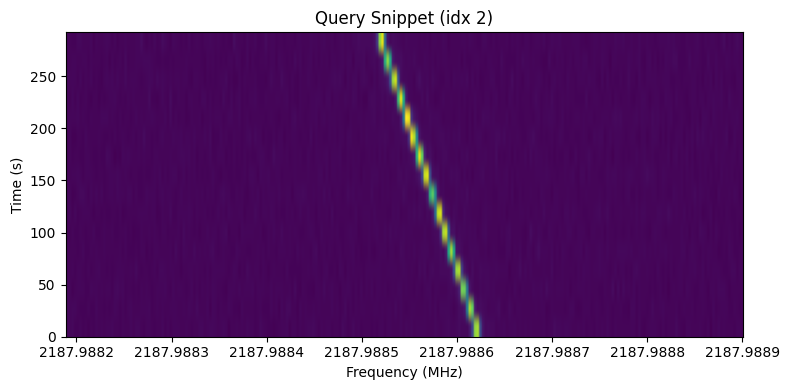

In [41]:
# === Visualize the query snippet (works with new _build_header_lookups) ===
query_snippet = snippets[300] # query_index
loc = snippet_locs[query_index]

header_info = _build_header_lookups(snippet_locs)   # ← single dict now
fname = loc[0]
tsamp = header_info[fname]["tsamp"]

def _extent_from_loc(loc, snippet_shape):
    n_time, n_cols = snippet_shape
    t1 = n_time * tsamp
    info = header_info[fname]
    f0_asc, df, nch = info["f0_asc"], info["df"], info["nch"]

    if len(loc) == 3:
        a, b = loc[1], loc[2]
        if isinstance(a, (int, np.integer)) and isinstance(b, (int, np.integer)) and 0 <= a < nch and 0 < b <= nch:
            f_lo = f0_asc + a * df
            f_hi = f0_asc + (b - 1) * df
            return [f_lo, f_hi, 0.0, t1], (f_lo, f_hi)
        else:
            f_lo, f_hi = float(a), float(b)
            return [f_lo, f_hi, 0.0, t1], (f_lo, f_hi)
    elif len(loc) >= 5:
        f_lo, f_hi = float(loc[3]), float(loc[4])
        return [f_lo, f_hi, 0.0, t1], (f_lo, f_hi)
    else:
        raise ValueError(f"Unsupported snippet_locs entry: {loc}")

extent, (freq_min, freq_max) = _extent_from_loc(loc, query_snippet.shape)

plt.figure(figsize=(8,4))
plt.imshow(query_snippet, aspect='auto', origin='lower', cmap='viridis', extent=extent)
plt.title(f"Query Snippet (idx {query_index})")
plt.xlabel("Frequency (MHz)")
plt.ylabel("Time (s)")
plt.tight_layout(); plt.show()


The above will visualize the query snippet and give us the indices of the 20 most similar snippets to it. Now, let's visualize the top 20 matches side by side. This will help us verify that the retrieved snippets look similar
in morphology (eg narrowband, drifting, etc.) to the query signal, even if they occur at different frequencies and/or times.

In [33]:
# Plot top 20 matches in a grid with real frequency and time axes
top20_idx = np.argsort(cosine_sim)[-20:][::-1]

# Cache frequencies and time resolution for each file
freq_lookup = {}
tsamp_lookup = {}
for fname in set(fname for fname, _, _ in snippet_locs):
  wf = Waterfall(fname, load_data=False)
  fch1 = wf.header['fch1']
  foff = wf.header['foff']
  nchans = wf.header['nchans']
  freqs = fch1 + np.arange(nchans) * foff
  freq_lookup[fname] = freqs
  tsamp_lookup[fname] = wf.header.get('tsamp', 1.0)

fig, axs = plt.subplots(4, 5, figsize=(20, 12))

for i, idx in enumerate(top20_idx):
    r, c = divmod(i, 5)
    ax = axs[r][c]

    snippet = snippets[idx]
    fname, f_start, f_end = snippet_locs[idx]
    freqs = freq_lookup[fname]
    tsamp = tsamp_lookup[fname]
    snippet_freqs = freqs[f_start:f_end]

    freq_min, freq_max = snippet_freqs[0], snippet_freqs[-1]
    time_max = snippet.shape[0] * tsamp  # seconds

    extent = [freq_min, freq_max, 0, time_max]

    ax.imshow(snippet, aspect='auto', origin='lower', cmap='viridis', extent=extent)

    short_name = Path(fname).name
    if len(short_name) > 40:
      short_name = f"…{short_name[-40:]}"

    ax.set_title(
      f"Snippet {idx}: {short_name}\n"
      f"$\\mathbf{{sim={cosine_sim[idx]:.2f}}}$\n"
      f"{freq_min/1e6:.6f}–{freq_max/1e6:.6f} MHz",
      fontsize=9
    )

    ax.set_xlabel("Frequency (Hz)")
    ax.set_ylabel("Time (s)")

plt.suptitle("Top 20 Similar Snippets to Query", fontsize=16)
plt.tight_layout()
plt.show()

ValueError: too many values to unpack (expected 3)

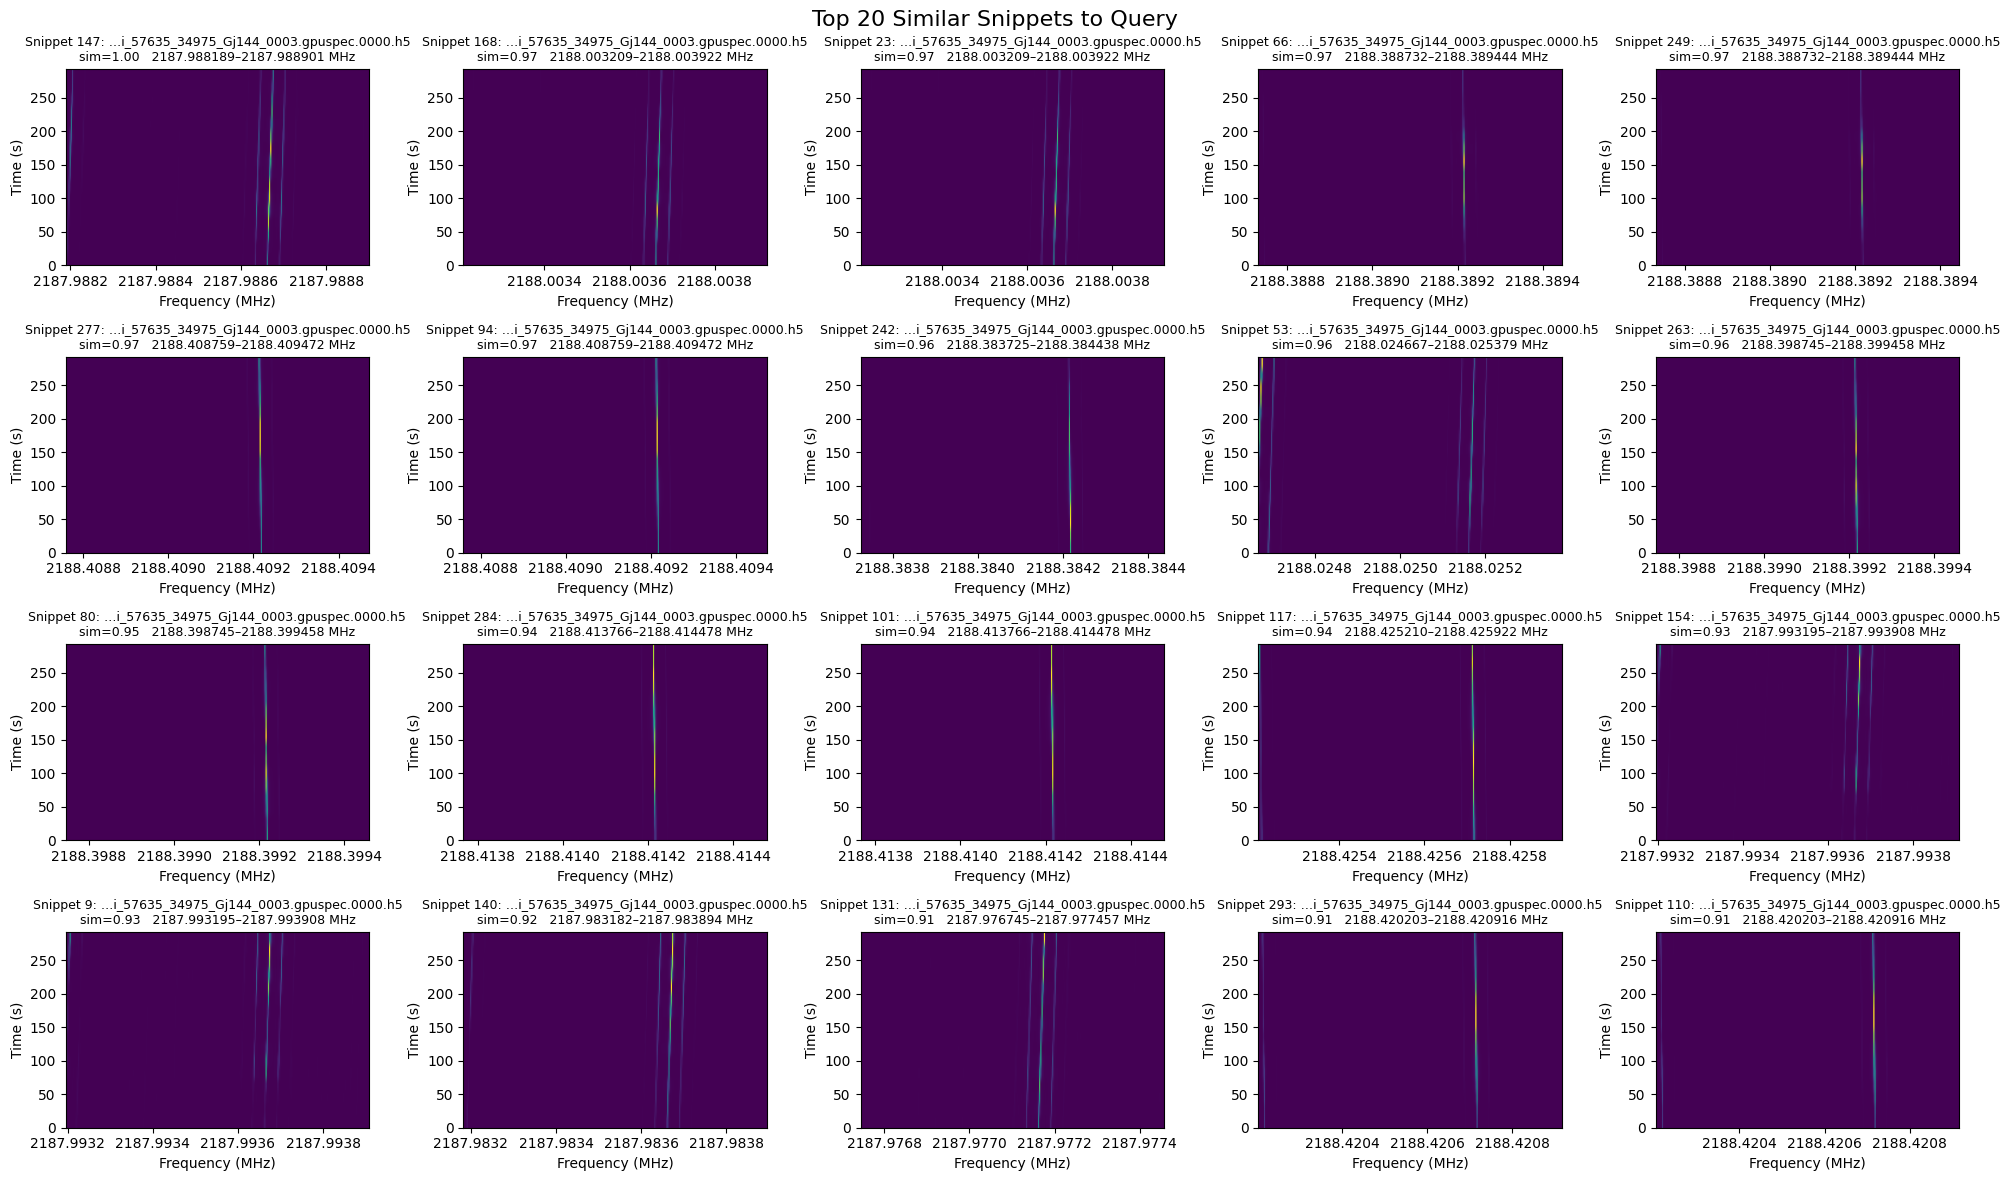

In [42]:
import numpy as np
import matplotlib.pyplot as plt
from blimpy import Waterfall
from pathlib import Path

# Top-20 by cosine similarity
top20_idx = np.argsort(cosine_sim)[-20:][::-1]

# ---- Build per-file header info (works regardless of tuple length) ----
def build_header_info(snippet_locs):
    files = {loc[0] for loc in snippet_locs}
    info = {}
    for fname in files:
        wf = Waterfall(fname, load_data=False)
        hdr = wf.header
        fch1  = float(hdr['fch1'])            # MHz
        foff  = float(hdr['foff'])            # MHz/bin (may be negative)
        df    = abs(foff)                     # MHz/bin positive
        nch   = int(hdr['nchans'])
        f0_asc = fch1 + (nch - 1) * foff if foff < 0 else fch1  # lowest MHz in ascending order
        tsamp = float(hdr.get('tsamp', 1.0))  # seconds
        info[fname] = dict(f0_asc=f0_asc, df=df, nch=nch, tsamp=tsamp)
    return info

header = build_header_info(snippet_locs)

# ---- Parse a snippet_locs entry into a plotting extent in MHz ----
def extent_from_loc(loc, snippet_shape):
    fname = loc[0]
    n_time, n_cols = snippet_shape
    tsamp = header[fname]["tsamp"]
    t1 = n_time * tsamp

    # Case A: (fname, k_lo, k_hi) -> indices in ascending frequency
    if len(loc) == 3 and all(isinstance(x, (int, np.integer)) for x in loc[1:]):
        k_lo, k_hi = int(loc[1]), int(loc[2])
        f0 = header[fname]["f0_asc"] + k_lo * header[fname]["df"]
        f1 = header[fname]["f0_asc"] + (k_hi - 1) * header[fname]["df"]
        return [f0, f1, 0.0, t1]

    # Case B: (fname, f_lo_MHz, f_hi_MHz) -> explicit MHz
    if len(loc) == 3:
        f0, f1 = float(loc[1]), float(loc[2])
        return [f0, f1, 0.0, t1]

    # Case C: (fname, k_lo, k_hi, f_lo_MHz, f_hi_MHz) -> prefer the explicit MHz
    if len(loc) >= 5:
        f0, f1 = float(loc[3]), float(loc[4])
        return [f0, f1, 0.0, t1]

    raise ValueError(f"Unsupported snippet_locs entry: {loc}")

# ---- Plot grid ----
fig, axs = plt.subplots(4, 5, figsize=(20, 12))
axs = np.atleast_2d(axs)

for i, idx in enumerate(top20_idx):
    r, c = divmod(i, 5)
    ax = axs[r, c]

    snippet = snippets[idx]
    loc = snippet_locs[idx]
    extent = extent_from_loc(loc, snippet.shape)  # [f0, f1, 0, t1] in MHz

    ax.imshow(snippet, aspect='auto', origin='lower', cmap='viridis', extent=extent)

    fname = loc[0]
    short = Path(fname).name
    if len(short) > 40:
        short = f"…{short[-40:]}"

    # Title shows similarity and MHz (no /1e6 needed)
    ax.set_title(
        f"Snippet {idx}: {short}\n"
        f"sim={cosine_sim[idx]:.2f}   "
        f"{extent[0]:.6f}–{extent[1]:.6f} MHz",
        fontsize=9
    )
    ax.set_xlabel("Frequency (MHz)")
    ax.set_ylabel("Time (s)")

# Hide any unused axes (in case <20)
for j in range(len(top20_idx), 20):
    r, c = divmod(j, 5)
    axs[r, c].axis("off")

plt.suptitle("Top 20 Similar Snippets to Query", fontsize=16)
plt.tight_layout()
plt.show()


After running the above, you should see a grid of 20 spectrogram patches. They are the snippets our
algorithm judged most similar to the query snippet, in order. If our query was Voyager's carrier, the top matches will
likely include other appearances of the Voyager signal (if present in multiple scans) or other narrowband
signals with similar drift slopes.  Visually, we expect these retrieved snippets to all show narrow,
possibly drifting lines, as opposed to pure noise. This confirms that the β-VAE has learned to represent
the morphological signature of the signal in latent space, and clustering in that space correlates with
visual similarity.

### 💪 Power Spectrum Plot
Now, if we want to, we can show the power spectrum of one of the top-matching signal snippets, averaged over time. The power spectrum reveals the frequency-dependent structure of the signal, making it easier to spot narrowband features like carrier tones. You can adjust snippet_id to inspect different results from the top 20 matches. This is useful for confirming whether high-similarity hits exhibit Voyager-like spectral characteristics.

In [36]:

# Plot the power spectrum of a selected top matching snippet (change `snippet_id` to inspect others)

snippet_id = top20_idx[0]  # Index 0 corresponds to the highest similarity hit. Change this number to inspect other top 20 snippets.
snippet = snippets[snippet_id]
fname, f_start, f_end = snippet_locs[snippet_id]

# Get frequency axis for that snippet
freqs = freq_lookup[fname][f_start:f_end]
spectrum = np.mean(snippet, axis=0)  # average over time

plt.figure(figsize=(10, 4))
plt.plot(freqs, spectrum)
plt.title(f"Power Spectrum of Snippet {snippet_id}\n{Path(fname).name}")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Average Power")
plt.grid(True)
plt.show()

ValueError: too many values to unpack (expected 3)

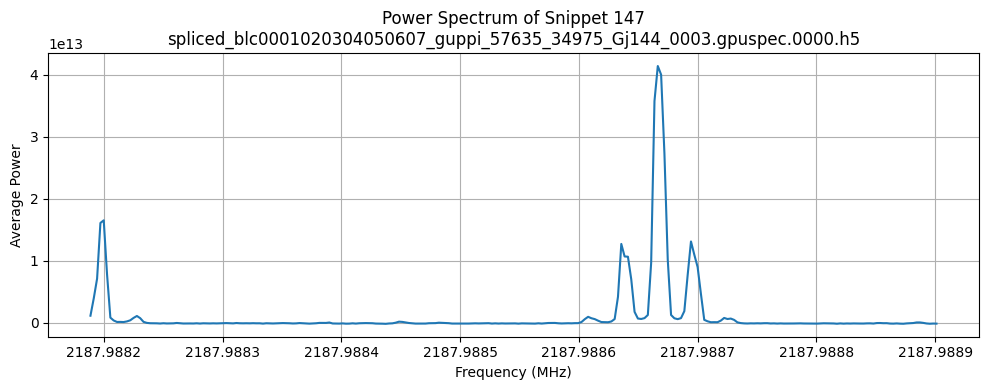

In [37]:
import numpy as np
import matplotlib.pyplot as plt
from blimpy import Waterfall
from pathlib import Path

# --- small helpers ---
def build_header_info(snippet_locs):
    files = {loc[0] for loc in snippet_locs}
    info = {}
    for fname in files:
        wf = Waterfall(fname, load_data=False)
        hdr = wf.header
        fch1  = float(hdr['fch1'])          # MHz
        foff  = float(hdr['foff'])          # MHz/bin (may be negative)
        df    = abs(foff)                   # MHz/bin (positive)
        nch   = int(hdr['nchans'])
        f0_asc = fch1 + (nch - 1) * foff if foff < 0 else fch1  # lowest MHz
        tsamp = float(hdr.get('tsamp', 1.0))
        info[fname] = dict(f0_asc=f0_asc, df=df, nch=nch, tsamp=tsamp)
    return info

def snippet_freq_axis(loc, snippet_shape, header):
    """Return (fname, freqs_MHz) for a snippet_locs entry, regardless of tuple format."""
    fname = loc[0]
    n_time, n_cols = snippet_shape
    info = header[fname]
    if len(loc) == 3:
        a, b = loc[1], loc[2]
        # indices case
        if isinstance(a, (int, np.integer)) and isinstance(b, (int, np.integer)) and 0 <= a < info["nch"] and 0 < b <= info["nch"]:
            k_lo, k_hi = int(a), int(b)
            f0 = info["f0_asc"] + k_lo * info["df"]
            f1 = info["f0_asc"] + (k_hi - 1) * info["df"]
        else:
            # MHz case
            f0, f1 = float(a), float(b)
    elif len(loc) >= 5:
        # (fname, k_lo, k_hi, f_lo_MHz, f_hi_MHz) -> use MHz directly
        f0, f1 = float(loc[3]), float(loc[4])
    else:
        raise ValueError(f"Unsupported snippet_locs entry: {loc}")

    if n_cols == 1:
        freqs = np.array([f0], dtype=float)
    else:
        freqs = np.linspace(f0, f1, n_cols, dtype=float)
    return fname, freqs

# --- choose which snippet to inspect ---
snippet_id = int(top20_idx[0])  # change this to look at others
snippet = snippets[snippet_id]

# build header cache once
header = build_header_info(snippet_locs)

# get frequency axis (MHz) robustly
fname, freqs_mhz = snippet_freq_axis(snippet_locs[snippet_id], snippet.shape, header)

# average over time for power spectrum
spectrum = np.mean(snippet, axis=0)

plt.figure(figsize=(10,4))
plt.plot(freqs_mhz, spectrum)
plt.title(f"Power Spectrum of Snippet {snippet_id}\n{Path(fname).name}")
plt.xlabel("Frequency (MHz)")   # <-- MHz, not Hz
plt.ylabel("Average Power")
plt.grid(True)
plt.tight_layout()
plt.show()


## 🔴 Activity 1: Find a Martian Satellite!

The reverse image search should work with other data sets too! We've included a dataset of 6 ON/OFF scans of Mars by the Greenbank telescope from 2020 ([see Ellie White's Tutorial](https://www.kaggle.com/code/elliewhite/breakthrough-listen-mars-tutorial)). You can test this data for yourself by changing *data_urls_voyager.lst* to *data_urls_mars.lst* under the **⏳💾 Data Loading** code section above and rerunning that and all following cells.

## 🔭 Activity 2: Explore the Breakthrough Listen Catalog!

Breakthrough Listen is an open-source and open-data project, which means that most of the data it has collected is publicly available! Navigate to http://seti.berkeley.edu/opendata. Then click on "Advanced Search Options" and uncheck all the boxes except for GBT and .hdf5 to make sure that you're getting similar files to the ones we've used in this tutorial. Then pick a dataset--any dataset! Just make sure you pay attention to the file size. You probably don't want to download any Gigabyte-sized files...

See if you can search one of these files for Voyager-like signals! If you find anything interesting, well... maybe let us know ;-) bsrc@berkeley.edu

## 🌌 Conclusion

We have demonstrated an end-to-end workflow for reverse-similarity search on Voyager 1’s radio spectrogram data: Starting from raw spectrogram files, we detected  candidate signals via a simple energy threshold (mimicking an energy detector). We used a pretrained β-VAE encoder to compress each signal snippet into a low-dimensional feature vector. By comparing these feature vectors with a cosine similarity metric, we identified signals that are morphologically similar to a given query signal. The top matches, when visualized, show spectrogram patterns resembling the query (e.g. narrowband drifting tones), validating the effectiveness of the learned representation in capturing signal shape.

This approach can greatly accelerate the vetting of candidate signals in SETI searches: rather than manually inspecting thousands of events, one can automatically find “lookalikes” of an interesting signal to determine if it was unique or part of a broader class (like common RFI). Our tutorial focused on a single query and a simplified detector, but the same pipeline can be extended. In a real scenario, one might incorporate multiple  queries,  more  sophisticated  RFI  rejection (using ON/OFF  comparisons ), and additional metadata (e.g. frequency embedding as in the full algorithm) to refine the search.

## 🙏 Credits and Gratitude
Many thanks to ChatGPT for writing the first draft of this tutorial, helping enormously with debugging, and teaching me a lot about how machine learning works! Also a ton of gratitude to Dr. Steve Croft for giving me the opportunity to work on this and his guidance, Peter Ma for actually making the model and gratitude to all other earthlings and aliens alike! ❤️❤️❤️🦋🐙🐍🐻🤖👽❤️❤️❤️

## 📚 References

The methodology and model used here are based on Peter Ma et al., 2023, who provide the open-source code and trained models. The Voyager 1 data is courtesy of the Breakthrough Listen project’s public archive. We encourage interested readers to explore these sources for a deeper understanding and potential
extensions of this reverse search technique!



1.   [Peter Ma et al.'s original 2023 paper.](https://academic.oup.com/rasti/article/3/1/33/7478003)
2.   [Peter Ma's "Reverse Radio Search" Github Repository](https://github.com/PetchMa/Reverse_Radio_Search).
3.   More data from Voyager 1 – Daniel Estévez
https://destevez.net/2021/12/more-data-from-voyager-1/
4.   scispace.com
https://scispace.com/pdf/a-deep-neural-network-based-reverse-radio-spectrogram-search-14vk4sqv.pdf